In [2]:
import pandas as pd

print(pd.__version__)

3.0.3


In [4]:
import os

print(os.getcwd())

/workspaces/FUTURE_ML_03/notebook


In [5]:
import os

print(os.listdir("."))

['Support_Ticket_Classification.ipynb']


In [6]:
import os

print(os.listdir("../"))

['images', 'notebook', 'requirements.txt', 'data', 'README.md', '.git']


In [7]:
print(os.listdir("../data"))

[]


In [8]:
import os
print(os.listdir("../data"))

['customer_support_tickets.csv']


In [9]:
import pandas as pd

df = pd.read_csv("../data/customer_support_tickets.csv")

print(df.shape)
df.head()

(8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [10]:
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [11]:
tickets = df[
    ["Ticket Description",
     "Ticket Type",
     "Ticket Priority"]
].copy()

tickets.head()

,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [12]:
tickets.dropna(inplace=True)

print(tickets.shape)

(8469, 3)


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = vectorizer.fit_transform(
    tickets["Ticket Description"]
)

In [14]:
from sklearn.model_selection import train_test_split

y = tickets["Ticket Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](5,)","[1277.,1368.,1325.,1407.,1398.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](5,)","[-1.67,-1.6 ,-1.63,-1.57,-1.58]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U20](5,)","['Billing inquiry','Cancellation request','Product inquiry', 'Refund request','Technical issue']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](5, 5000)","[[5.15,2.3 ,0. ,...,0.31,0.75,0. ], [4.63,0.94,0. ,...,0. ,0. ,0.34], [5.78,2.68,0. ,...,0. ,0. ,0. ], [2.88,1.64,0. ,...,0. ,0. ,0.37], [2.57,1.75,0. ,...,0. ,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](5, 5000)","[[-7.4 ,-8.02,-9.21,...,-8.94,-8.65,-9.21], [-7.52,-8.59,-9.25,...,-9.25,-9.25,-8.96], [-7.32,-7.93,-9.23,...,-9.23,-9.23,-9.23], [-7.9 ,-8.29,-9.26,...,-9.26,-9.26,-8.95], [-7.98,-8.24,-9.26,...,-9.26,-9.26,-9.26]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [16]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.1959858323494687


In [17]:
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [18]:
from sklearn.model_selection import train_test_split

y_priority = tickets["Ticket Priority"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.naive_bayes import MultinomialNB

priority_model = MultinomialNB()

priority_model.fit(
    X_train_p,
    y_train_p
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](4,)","[1718.,1676.,1648.,1733.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](4,)","[-1.37,-1.4 ,-1.41,-1.36]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](4,)","['Critical','High','Low','Medium']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](4, 5000)","[[3.8 ,1.96,0. ,...,0. ,0. ,0.37], [4.26,2.81,0. ,...,0. ,0.75,0. ], [5.81,2.46,0. ,...,0. ,0. ,0.34], [7.14,2.07,0. ,...,0.31,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](4, 5000)","[[-7.8 ,-8.28,-9.37,...,-9.37,-9.37,-9.05], [-7.7 ,-8.02,-9.36,...,-9.36,-8.8 ,-9.36], [-7.43,-8.11,-9.35,...,-9.35,-9.35,-9.06], [-7.28,-8.25,-9.38,...,-9.11,-9.38,-9.38]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [20]:
from sklearn.metrics import accuracy_score

priority_predictions = priority_model.predict(
    X_test_p
)

priority_accuracy = accuracy_score(
    y_test_p,
    priority_predictions
)

print("Priority Accuracy:", priority_accuracy)

Priority Accuracy: 0.2502951593860685


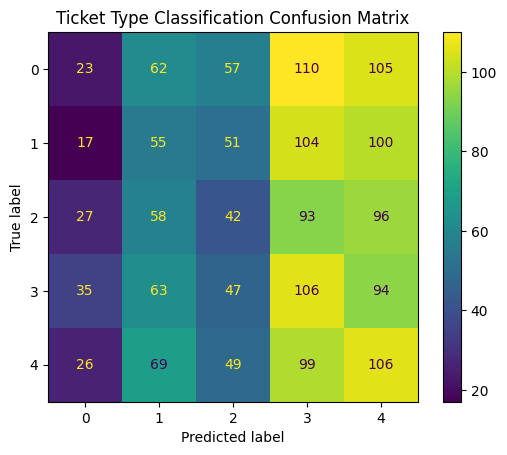

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Ticket Type Classification Confusion Matrix")
plt.show()

In [22]:
sample_ticket = [
    "Unable to login to my account after password reset"
]

sample_vector = vectorizer.transform(
    sample_ticket
)

predicted_type = model.predict(
    sample_vector
)

predicted_priority = priority_model.predict(
    sample_vector
)

print("Predicted Category:", predicted_type[0])
print("Predicted Priority:", predicted_priority[0])

Predicted Category: Cancellation request
Predicted Priority: Medium


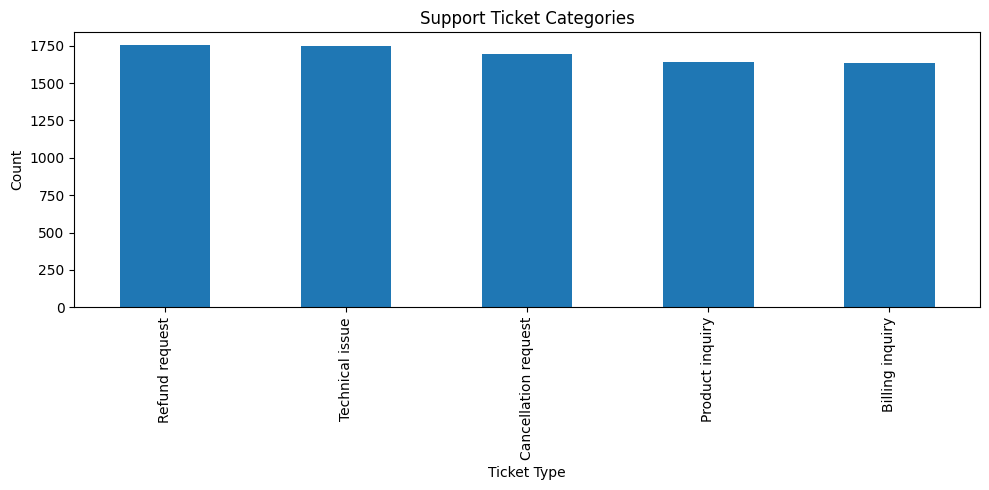

In [23]:
import matplotlib.pyplot as plt

ticket_counts = tickets["Ticket Type"].value_counts()

plt.figure(figsize=(10,5))

ticket_counts.plot(kind="bar")

plt.title("Support Ticket Categories")
plt.xlabel("Ticket Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()